# Common Data Preprocessing Pipeline

This notebook performs **all data preprocessing once** and saves the results so that all 4 models
(Linear Regression, Decision Tree, Random Forest, SVR) use the **exact same preprocessed dataset**.

**Run this notebook FIRST before running any model notebook.**

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load the Dataset

In [ ]:
# Load the dataset
df = pd.read_csv('../data/StudentPerformanceFactors.csv')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names: {df.columns.tolist()}")
df.head()

Dataset Shape: 6607 rows × 20 columns

Column Names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 2. Exploratory Data Analysis (EDA)

In [ ]:
# Data types and basic info
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)
print(f"\nNumerical columns: {df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"Categorical columns: {df.select_dtypes(include=['object']).columns.tolist()}")

DATA TYPES
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

Numerical columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activit

In [ ]:
# Statistical summary
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

STATISTICAL SUMMARY


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [ ]:
# Missing values analysis
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUES
                          Missing Count  Percentage (%)
Teacher_Quality                      78            1.18
Parental_Education_Level             90            1.36
Distance_from_Home                   67            1.01

Total missing values: 235


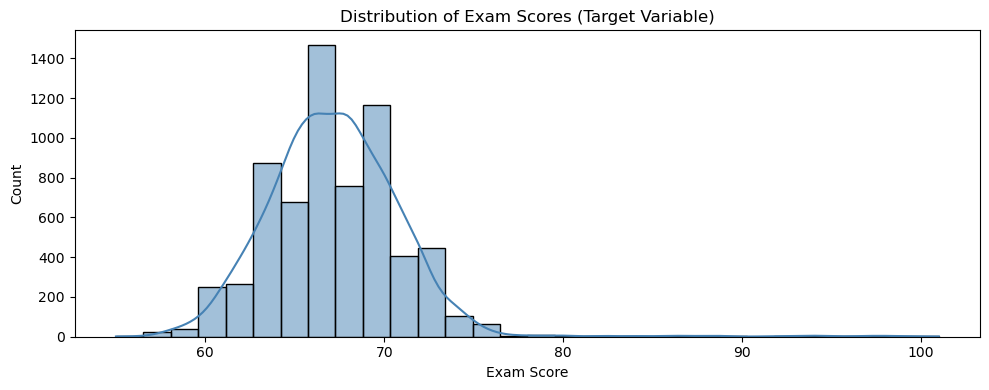

Target Statistics:
count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


In [ ]:
# Target variable distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['Exam_Score'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Exam Scores (Target Variable)')
plt.xlabel('Exam Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Target Statistics:\n{df['Exam_Score'].describe()}")

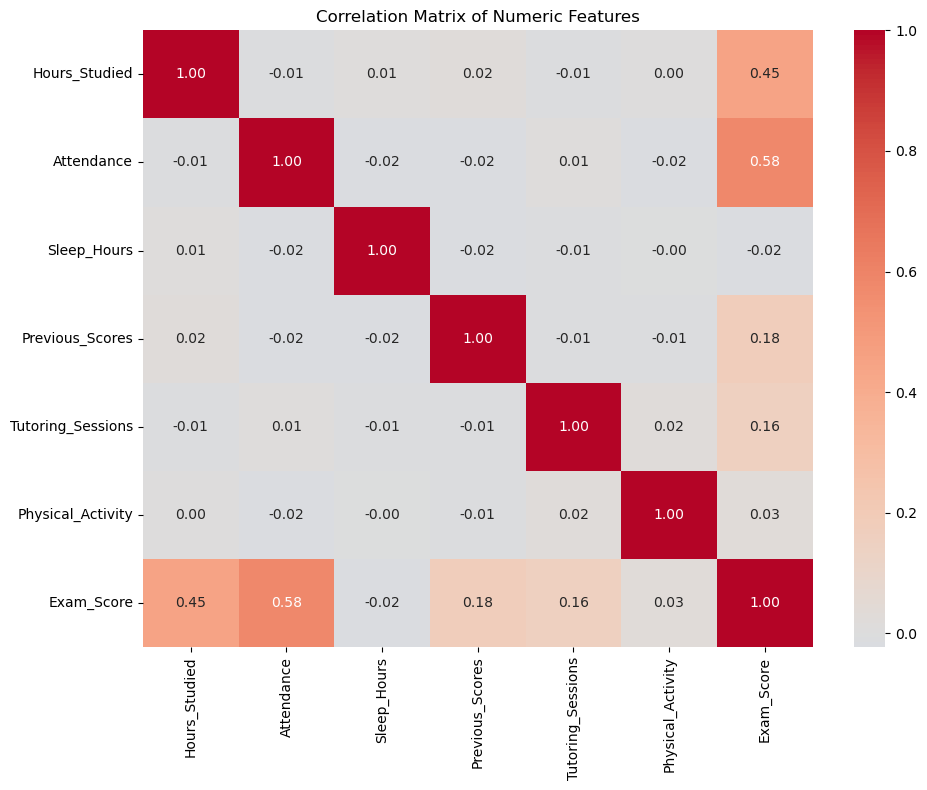

In [ ]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

## 3. Data Cleaning — Handle Missing Values

In [ ]:
# Create a copy for preprocessing
df_clean = df.copy()

# Identify column types
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Exam_Score')  # Remove target from features

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

Categorical columns (13): ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Numerical columns (6): ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']


In [ ]:
# Fill categorical missing values with mode
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: '{mode_val}'")

# Fill numerical missing values with the median
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

print(f"\nMissing values after cleaning: {df_clean.isnull().sum().sum()}")
print(f"Dataset shape after cleaning: {df_clean.shape}")  

Filled missing values in 'Teacher_Quality' with mode: 'Medium'
Filled missing values in 'Parental_Education_Level' with mode: 'High School'
Filled missing values in 'Distance_from_Home' with mode: 'Near'

Missing values after cleaning: 0
Dataset shape after cleaning: (6607, 20)


## 4. Outlier Detection (Z-Score Analysis)

In [ ]:
# Outlier detection using Z-score method
numeric_features = df_clean[numerical_cols + ['Exam_Score']]
z_scores = np.abs(stats.zscore(numeric_features))

outlier_mask = (z_scores > 3).any(axis=1)
num_outliers = outlier_mask.sum()

print(f"Number of outliers detected (Z-score > 3): {num_outliers}")
print(f"Percentage of data: {num_outliers / len(df_clean) * 100:.2f}%")

# Show outlier counts per column
outlier_counts = (z_scores > 3).sum(axis=0)
print(f"\nOutliers per column:")
for col, count in zip(numeric_features.columns, outlier_counts):
    if count > 0:
        print(f"  {col}: {count} outliers")


print("\nNote: Outliers are reported but NOT removed to maintain consistency.")

Number of outliers detected (Z-score > 3): 101
Percentage of data: 1.53%

Outliers per column:
  Hours_Studied: 25 outliers
  Tutoring_Sessions: 26 outliers
  Exam_Score: 52 outliers

Note: Outliers are reported but NOT removed to maintain consistency.


## 5. Encode Categorical Variables

In [ ]:
# Encode categorical variables using LabelEncoder
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoded dataset shape: {df_clean.shape}")
print(f"All columns are now numeric: {df_clean.dtypes.unique()}")
df_clean.head()

Encoded 'Parental_Involvement': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Encoded 'Access_to_Resources': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Encoded 'Extracurricular_Activities': {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded 'Motivation_Level': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Encoded 'Internet_Access': {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded 'Family_Income': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Encoded 'Teacher_Quality': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Encoded 'School_Type': {'Private': np.int64(0), 'Public': np.int64(1)}
Encoded 'Peer_Influence': {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
Encoded 'Learning_Disabilities': {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded 'Parental_Education_Level': {'College': np.int64(0), 'High School': np.int64(1), 'Postgraduate': np.int64(2)}
Encoded 'Distance_from_H

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


## 6. Feature-Target Split

In [ ]:
# Separate features (X) and target (y)
X = df_clean.drop('Exam_Score', axis=1)
y = df_clean['Exam_Score']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features shape: (6607, 19)
Target shape: (6607,)

Feature columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


## 7. Train-Test Split

In [ ]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Training set: 5285 samples
Testing set:  1322 samples

X_train shape: (5285, 19)
X_test shape:  (1322, 19)
y_train shape: (5285,)
y_test shape:  (1322,)


## 8. Feature Scaling

In [16]:
# Standardize features using StandardScaler
# Fit on training data only, then transform both train and test
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Feature scaling completed (StandardScaler).")
print(f"\nScaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape:  {X_test_scaled.shape}")
print(f"\nScaled training data sample:")
X_train_scaled.head()

Feature scaling completed (StandardScaler).

Scaled X_train shape: (5285, 19)
Scaled X_test shape:  (1322, 19)

Scaled training data sample:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
5810,1.173579,-0.075846,-0.254980,-1.385973,0.819074,0.669094,-0.837277,-1.682832,0.290771,0.405784,-0.285176,0.769204,0.659524,-1.576632,1.964909,-0.351443,-1.287764,-0.733098,-1.169997
1268,-0.661983,0.531894,-1.410702,0.910944,0.819074,-0.016740,1.314728,0.882431,0.290771,0.405784,-0.285176,-1.457717,0.659524,-0.260489,0.030381,-0.351443,0.146250,-0.733098,-1.169997
414,0.339232,0.618714,-0.254980,0.910944,-1.220891,0.669094,0.551113,-0.400200,0.290771,-0.405017,-0.285176,0.769204,0.659524,-0.260489,-1.904146,-0.351443,-1.287764,-2.219831,0.854703
4745,-0.328245,1.747376,-1.410702,0.910944,0.819074,2.040764,0.759372,0.882431,0.290771,-0.405017,1.064113,0.769204,0.659524,-0.260489,0.030381,-0.351443,0.146250,0.753634,0.854703
654,2.508533,-0.162667,-1.410702,-0.237515,0.819074,2.040764,1.661825,0.882431,0.290771,-0.405017,-0.285176,0.769204,-1.516246,1.055654,-0.936882,-0.351443,0.146250,0.753634,0.854703


## 9. Save Preprocessed Data

In [17]:
# Create output directory
output_dir = '../data/preprocessed'
os.makedirs(output_dir, exist_ok=True)

# Save unscaled data (for Decision Tree & Random Forest)
X_train.to_csv(f'{output_dir}/X_train.csv', index=False)
X_test.to_csv(f'{output_dir}/X_test.csv', index=False)
y_train.to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.to_csv(f'{output_dir}/y_test.csv', index=False)

# Save scaled data (for Linear Regression & SVR)
X_train_scaled.to_csv(f'{output_dir}/X_train_scaled.csv', index=False)
X_test_scaled.to_csv(f'{output_dir}/X_test_scaled.csv', index=False)

# Save encoders and scaler
joblib.dump(label_encoders, f'{output_dir}/label_encoders.pkl')
joblib.dump(scaler, f'{output_dir}/scaler.pkl')
joblib.dump(X.columns.tolist(), f'{output_dir}/feature_names.pkl')

print("=" * 50)
print("ALL PREPROCESSED DATA SAVED SUCCESSFULLY!")
print("=" * 50)
print(f"\nSaved to: {output_dir}/")
print(f"\nFiles saved:")
for f in sorted(os.listdir(output_dir)):
    size = os.path.getsize(f'{output_dir}/{f}')
    print(f"  {f} ({size:,} bytes)")

print(f"\n--- Summary ---")
print(f"Total samples: {len(df_clean)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {X.columns.tolist()}")
print(f"\nModels that should use UNSCALED data: Decision Tree, Random Forest")
print(f"Models that should use SCALED data: Linear Regression, SVR")

ALL PREPROCESSED DATA SAVED SUCCESSFULLY!

Saved to: ../data/preprocessed/

Files saved:
  X_test.csv (54,573 bytes)
  X_test_scaled.csv (489,137 bytes)
  X_train.csv (217,145 bytes)
  X_train_scaled.csv (1,954,558 bytes)
  feature_names.pkl (374 bytes)
  label_encoders.pkl (3,515 bytes)
  scaler.pkl (1,631 bytes)
  y_test.csv (3,977 bytes)
  y_train.csv (15,868 bytes)

--- Summary ---
Total samples: 6607
Training samples: 5285
Testing samples: 1322
Number of features: 19
Feature names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Models that should use UNSCALED data: Decision Tree, Random Forest
Models that should use SCALED data: Linear Regression, SVR
